In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Seismic Bumps Dataset

The **Seismic Bumps Dataset** is a multivariate classification dataset provided by the **UCI Machine Learning Repository**. It contains information about seismic activity recorded in underground coal mines in Poland.

Each record represents a summary of the seismic activity observed during an **8-hour work shift**. The dataset includes several measurements related to seismic energy, the number of seismic pulses and bumps, maximum recorded energy, and seismic hazard assessments.

The main objective is to **predict whether a hazardous seismic event will occur during the following shift**. A hazardous event is defined as a seismic bump with an energy greater than **10⁴ Joules**.

The target variable, `class`, is binary:

* **0 — Non-hazardous state:** No high-energy seismic bump occurred during the next shift.
* **1 — Hazardous state:** A high-energy seismic bump occurred during the next shift.

The dataset contains **2,584 observations and 18 input features**, making it a **binary classification problem**. One of the main challenges is the significant **class imbalance**, as only 170 observations belong to the hazardous class.

This dataset can therefore be used to investigate how machine learning models can identify patterns in seismic activity and provide an early indication of potentially hazardous conditions in underground mining operations.
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTnadinE-XXkbCuiLWKdoS9zktQ_Dlrqr4ejOyUX6_Uzg&s=10" width="1000" height="500">

# Data Loading & Understanding

In [4]:
df=pd.read_csv('/content/csv_result-seismic-bumps-1.csv')
df.head() # Display the first 5 rows

,id,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,nbumps7,nbumps89,energy,maxenergy,class
0,1,a,a,N,15180,48,-72,-72,a,0,0,0,0,0,0,0,0,0,0,0
1,2,a,a,N,14720,33,-70,-79,a,1,0,1,0,0,0,0,0,2000,2000,0
2,3,a,a,N,8050,30,-81,-78,a,0,0,0,0,0,0,0,0,0,0,0
3,4,a,a,N,28820,171,-23,40,a,1,0,1,0,0,0,0,0,3000,3000,0
4,5,a,a,N,12640,57,-63,-52,a,0,0,0,0,0,0,0,0,0,0,0


In [5]:
# check the shape of data
print("shape:", df.shape)
print('='*50)
# Display all column names
print("Column names:\n",df.columns.tolist())
print('='*50)
# get info
df.info()

shape: (2584, 20)
Column names:
 ['id', 'seismic', 'seismoacoustic', 'shift', 'genergy', 'gpuls', 'gdenergy', 'gdpuls', 'ghazard', 'nbumps', 'nbumps2', 'nbumps3', 'nbumps4', 'nbumps5', 'nbumps6', 'nbumps7', 'nbumps89', 'energy', 'maxenergy', 'class']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2584 entries, 0 to 2583
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              2584 non-null   int64 
 1   seismic         2584 non-null   object
 2   seismoacoustic  2584 non-null   object
 3   shift           2584 non-null   object
 4   genergy         2584 non-null   int64 
 5   gpuls           2584 non-null   int64 
 6   gdenergy        2584 non-null   int64 
 7   gdpuls          2584 non-null   int64 
 8   ghazard         2584 non-null   object
 9   nbumps          2584 non-null   int64 
 10  nbumps2         2584 non-null   int64 
 11  nbumps3         2584 non-null   int64 
 12  nbumps4         2584 

In [6]:
# statistical summary for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2584.0,1292.500000,746.080871,1.0,646.75,1292.5,1938.25,2584.0
genergy,2584.0,90242.523220,229200.508894,100.0,11660.00,25485.0,52832.50,2595650.0
gpuls,2584.0,538.579334,562.652536,2.0,190.00,379.0,669.00,4518.0
gdenergy,2584.0,12.375774,80.319051,-96.0,-37.00,-6.0,38.00,1245.0
gdpuls,2584.0,4.508901,63.166556,-96.0,-36.00,-6.0,30.25,838.0
nbumps,2584.0,0.859520,1.364616,0.0,0.00,0.0,1.00,9.0
nbumps2,2584.0,0.393576,0.783772,0.0,0.00,0.0,1.00,8.0
nbumps3,2584.0,0.392802,0.769710,0.0,0.00,0.0,1.00,7.0
nbumps4,2584.0,0.067724,0.279059,0.0,0.00,0.0,0.00,3.0
nbumps5,2584.0,0.004644,0.068001,0.0,0.00,0.0,0.00,1.0


In [7]:
# summary statistical for categorical columns
df.describe(include='object').T

,count,unique,top,freq
seismic,2584,2,a,1682
seismoacoustic,2584,3,a,1580
shift,2584,2,W,1663
ghazard,2584,3,a,2342


In [8]:
categorical_cols=df.select_dtypes(include='object').columns # categorical columns
# get values of each categorical columns
for col in categorical_cols:
  print('Column: ',col)
  print('Values:\n',df[col].value_counts())
  print('='*60)


Column:  seismic
Values:
 seismic
a    1682
b     902
Name: count, dtype: int64
Column:  seismoacoustic
Values:
 seismoacoustic
a    1580
b     956
c      48
Name: count, dtype: int64
Column:  shift
Values:
 shift
W    1663
N     921
Name: count, dtype: int64
Column:  ghazard
Values:
 ghazard
a    2342
b     212
c      30
Name: count, dtype: int64


Calculate the percentage of target class

In [9]:
print("Target class percentages: \n",df['class'].value_counts(normalize=True)*100)


Target class percentages: 
 class
0    93.421053
1     6.578947
Name: proportion, dtype: float64


There are implcanced data as class 1 represents 6.58% from data

check null values and duplicates

In [10]:
# check nulls
print('number of null values= ',df.isnull().sum().sum())

# check duplicates
print('number of duplicates= ',df.duplicated().sum())

number of null values=  0
number of duplicates=  0


check outliers

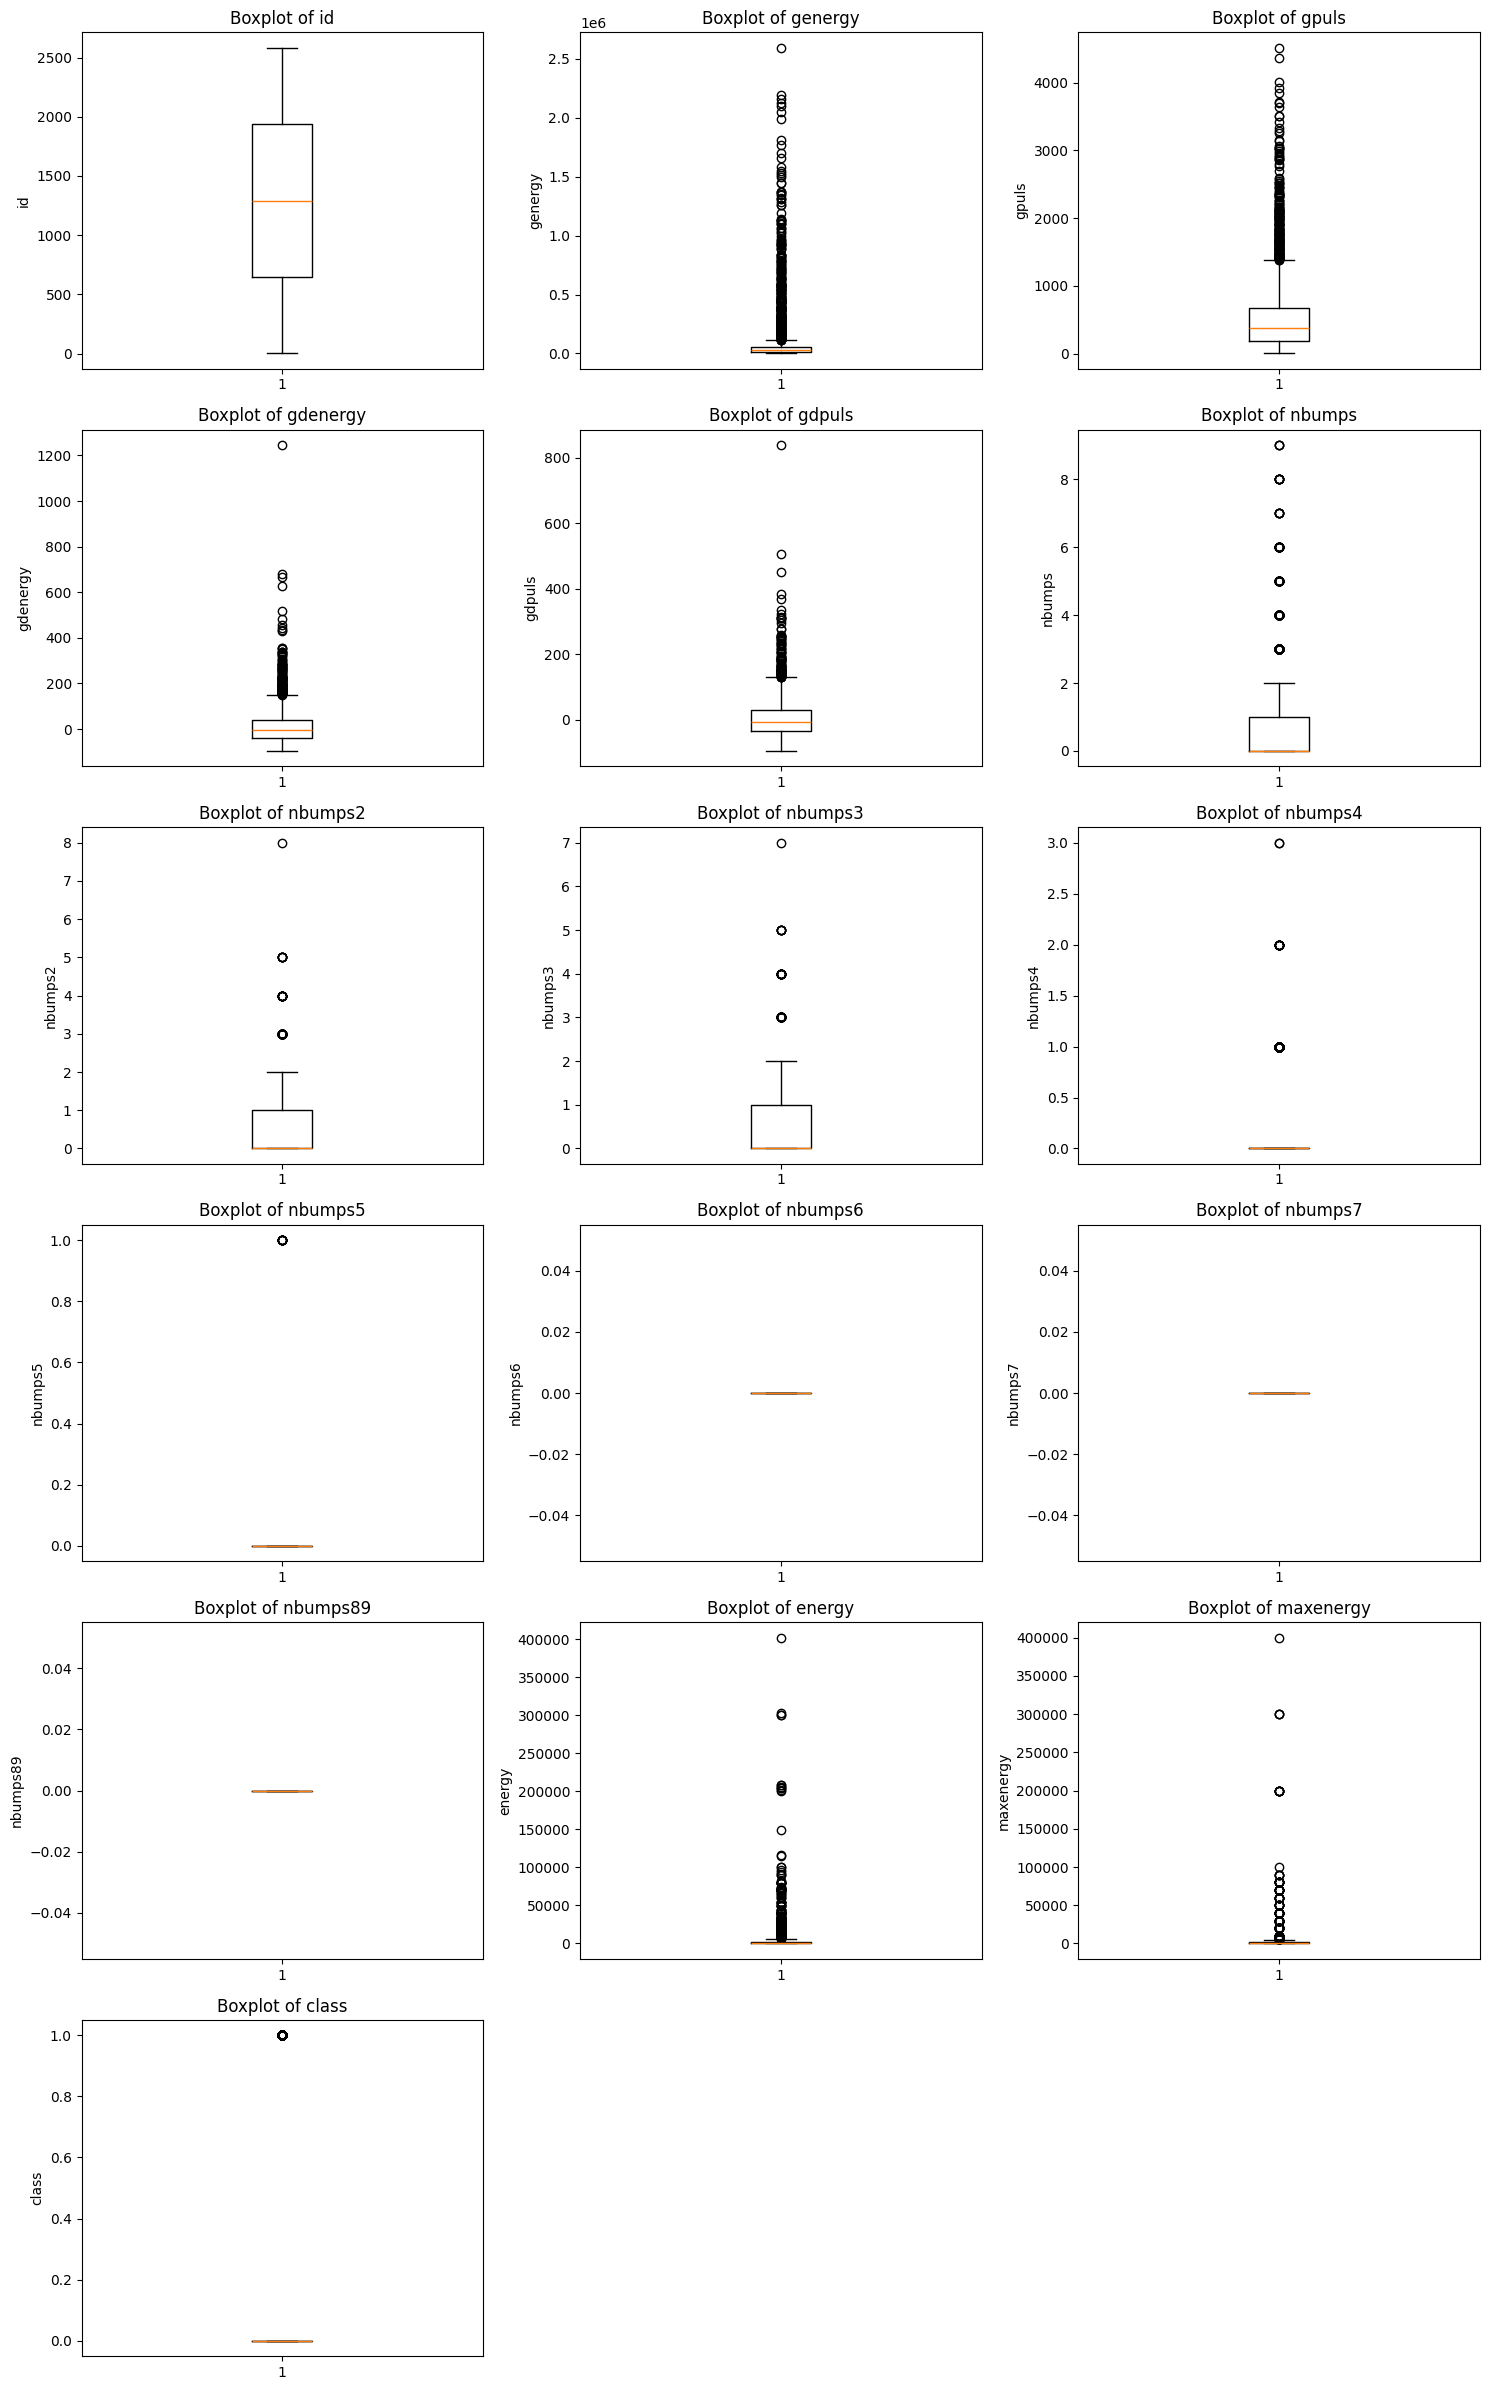

In [11]:
import math
# numerical columns
numerical_cols = df.select_dtypes('number').columns
# Calculate number of rows
n_rows = math.ceil(len(numerical_cols)/3)

# Create subplots
fig,axes = plt.subplots(
    n_rows,
    3,
    figsize=(15, 4 * n_rows)
)
# Flatten axes to make looping easier
axes = axes.flatten()
# make boxplot
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Hide empty subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

There are outliers in columns [genergy,gpuls,gdenergy(has negative values), gdpuls(has negative values),energy,maxenergy)

# Data Preprocessing

In [12]:
# take copy of data to keep original data unchanged
data=df.copy()

In [13]:
data.head()

,id,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,nbumps7,nbumps89,energy,maxenergy,class
0,1,a,a,N,15180,48,-72,-72,a,0,0,0,0,0,0,0,0,0,0,0
1,2,a,a,N,14720,33,-70,-79,a,1,0,1,0,0,0,0,0,2000,2000,0
2,3,a,a,N,8050,30,-81,-78,a,0,0,0,0,0,0,0,0,0,0,0
3,4,a,a,N,28820,171,-23,40,a,1,0,1,0,0,0,0,0,3000,3000,0
4,5,a,a,N,12640,57,-63,-52,a,0,0,0,0,0,0,0,0,0,0,0


## Feature Engineering

In [14]:
data.columns

Index(['id', 'seismic', 'seismoacoustic', 'shift', 'genergy', 'gpuls',
       'gdenergy', 'gdpuls', 'ghazard', 'nbumps', 'nbumps2', 'nbumps3',
       'nbumps4', 'nbumps5', 'nbumps6', 'nbumps7', 'nbumps89', 'energy',
       'maxenergy', 'class'],
      dtype='object')

Bump-count features

In [15]:
# if any row has any bump
data['has_any_bump']= (data['nbumps']>0).astype(int)
# if any row has bump89 because it has most energy class
data['has_high_energy_bump']= (data['nbumps89'] > 0).astype(int)

In [16]:
# High-energy bump columns
high_energy_cols=[
    'nbumps4',
    'nbumps5',
    'nbumps6',
    'nbumps7',
    'nbumps89'
]
# Number of high-energy bumps
data['high_energy_bumps']=data[high_energy_cols].sum(axis=1)
# Low-energy bump columns
low_energy_cols=[
    'nbumps2',
    'nbumps3'
]

# Number of low-energy bumps
data['low_energy_bumps']=data[low_energy_cols].sum(axis=1)

Energy feature

In [17]:
# high energy ratio
data['high_energy_ratio']=(
    data['high_energy_bumps'] /
    (data['nbumps']+ 1) # to avoid nbump=0
)
# Average energy per bump
data['avg_energy_per_bump']=(
    data['energy'] /
    (data['nbumps']+ 1)# to avoid nbump=0
)

# Energy per pulse
data['energy_per_pulse']=(
    data['genergy'] /
    (data['gpuls']+ 1)# to avoid nbump=0
)
# if deviation are positive means if hazard are larger than usual
data['both_positive_dev']=((data['gdenergy']>0)&(data['gdpuls']>0)).astype(int)
# if deviation are negative means if hazard are smaller than usual
data['both_negative_dev']=((data['gdenergy']<0)&(data['gdpuls']<0)).astype(int)
# the power of deviation
data['dev_magnitude']= np.sqrt(data['gdenergy']**2+data['gdpuls']**2)

Hazard assessment

In [18]:
# if three sources agree as same type of hazard
data['hazard_agreement']=(data['seismic']==data['seismoacoustic'])&(data['seismoacoustic']==data['ghazard'])

# if one of them say c or higher as high hazard
data['any_high_hazard']=(data[['seismic', 'seismoacoustic', 'ghazard']]=='c').any(axis=1).astype(int)

##  Handle outliers

In [19]:
data.columns

Index(['id', 'seismic', 'seismoacoustic', 'shift', 'genergy', 'gpuls',
       'gdenergy', 'gdpuls', 'ghazard', 'nbumps', 'nbumps2', 'nbumps3',
       'nbumps4', 'nbumps5', 'nbumps6', 'nbumps7', 'nbumps89', 'energy',
       'maxenergy', 'class', 'has_any_bump', 'has_high_energy_bump',
       'high_energy_bumps', 'low_energy_bumps', 'high_energy_ratio',
       'avg_energy_per_bump', 'energy_per_pulse', 'both_positive_dev',
       'both_negative_dev', 'dev_magnitude', 'hazard_agreement',
       'any_high_hazard'],
      dtype='object')

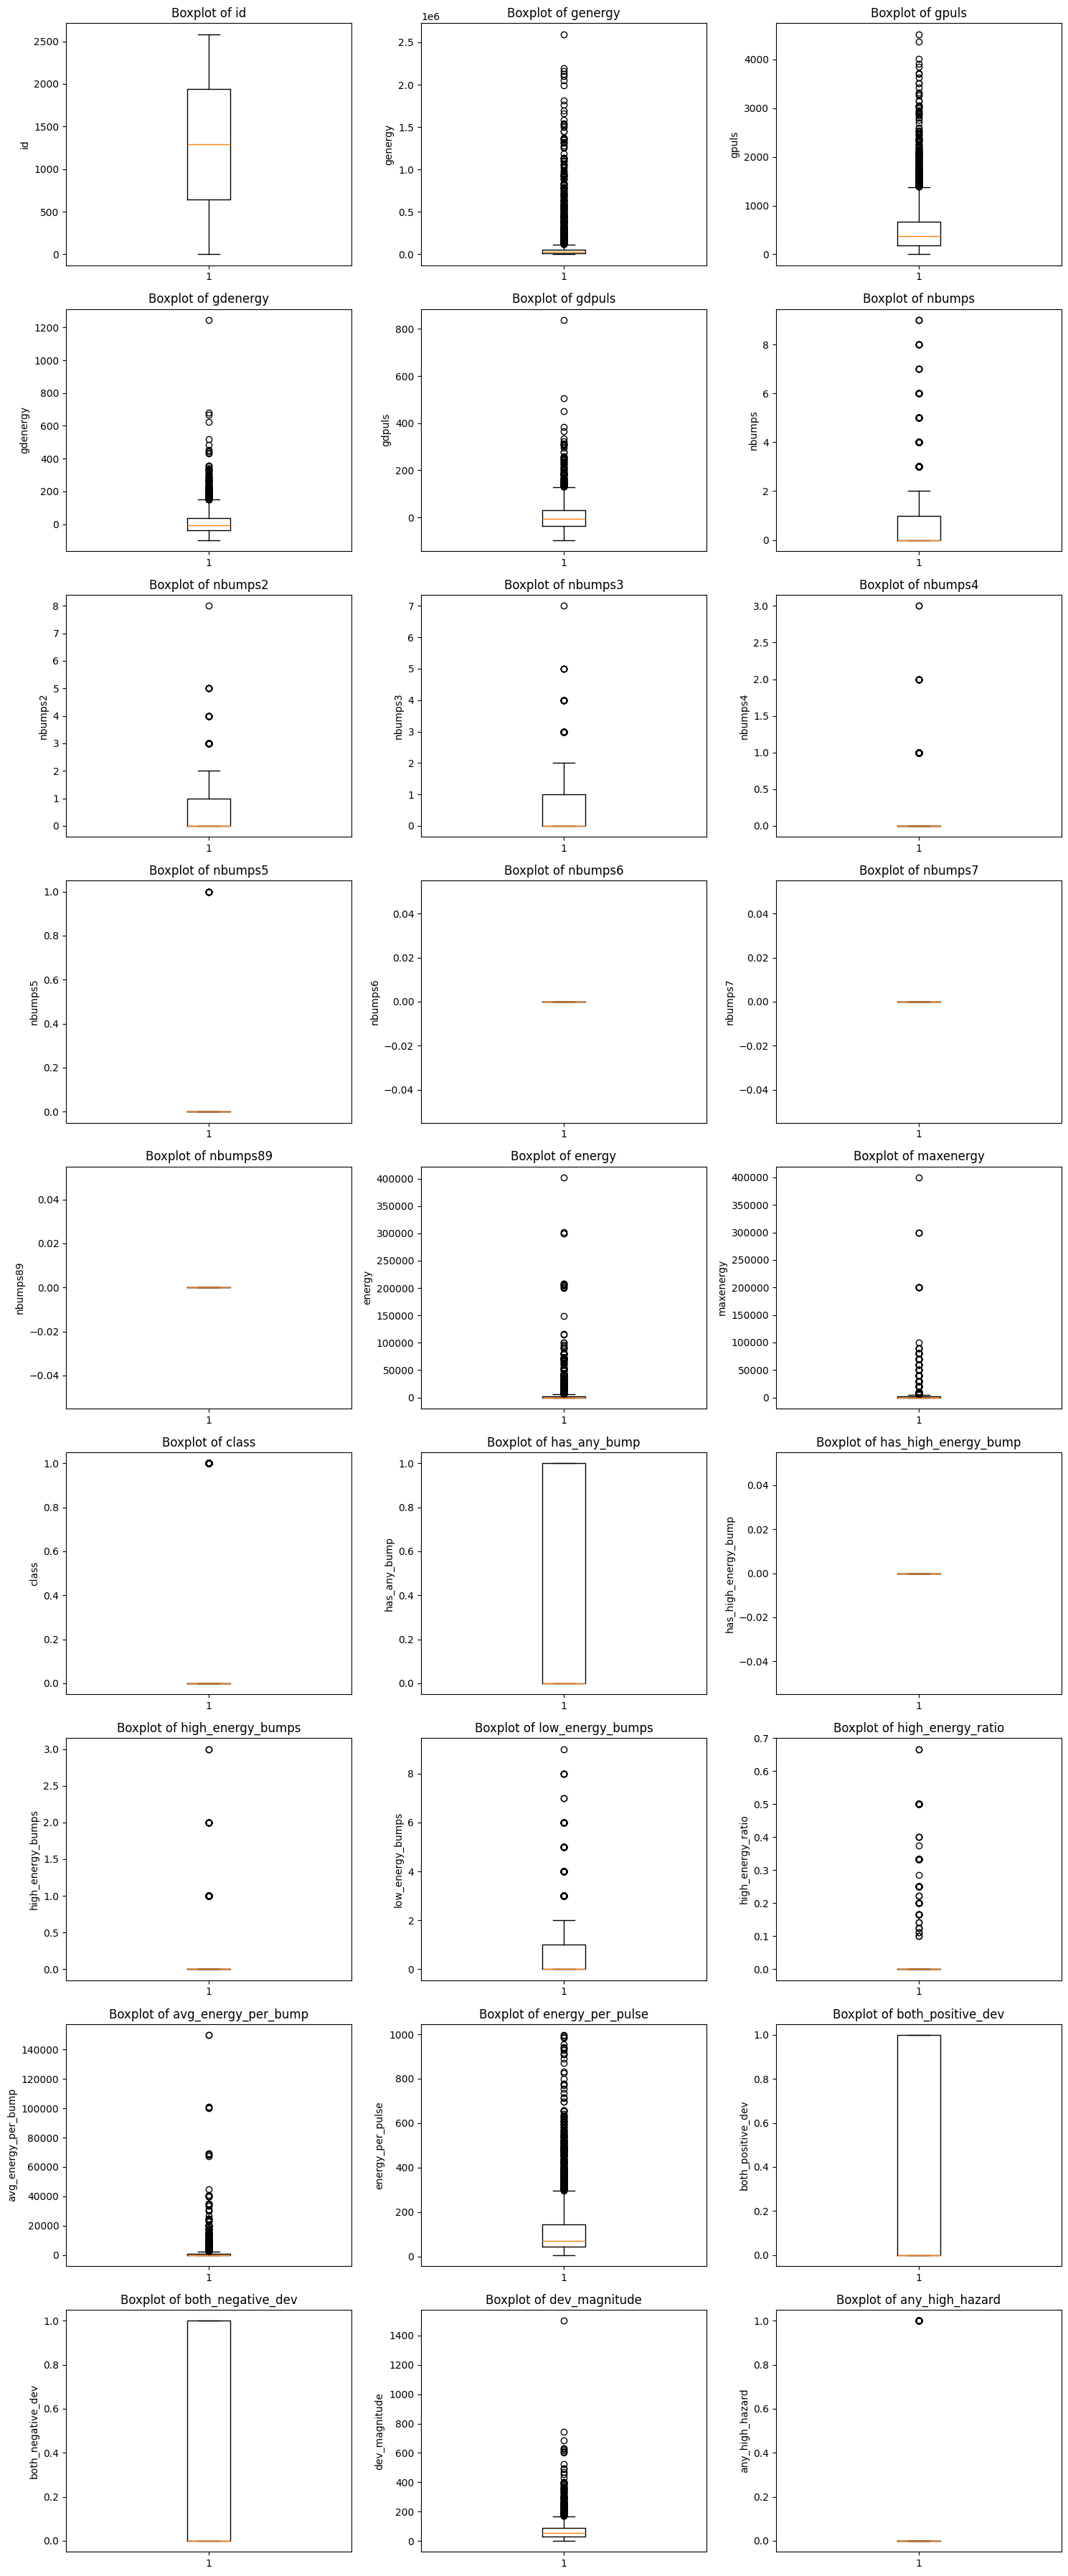

In [20]:
numerical_cols = data.select_dtypes('number').columns
# Calculate number of rows
n_rows = math.ceil(len(numerical_cols)/3)

# Create subplots
fig,axes = plt.subplots(
    n_rows,
    3,
    figsize=(15, 4 * n_rows)
)
# Flatten axes to make looping easier
axes = axes.flatten()
# make boxplot
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(data[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Hide empty subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

hist plot to check skewness

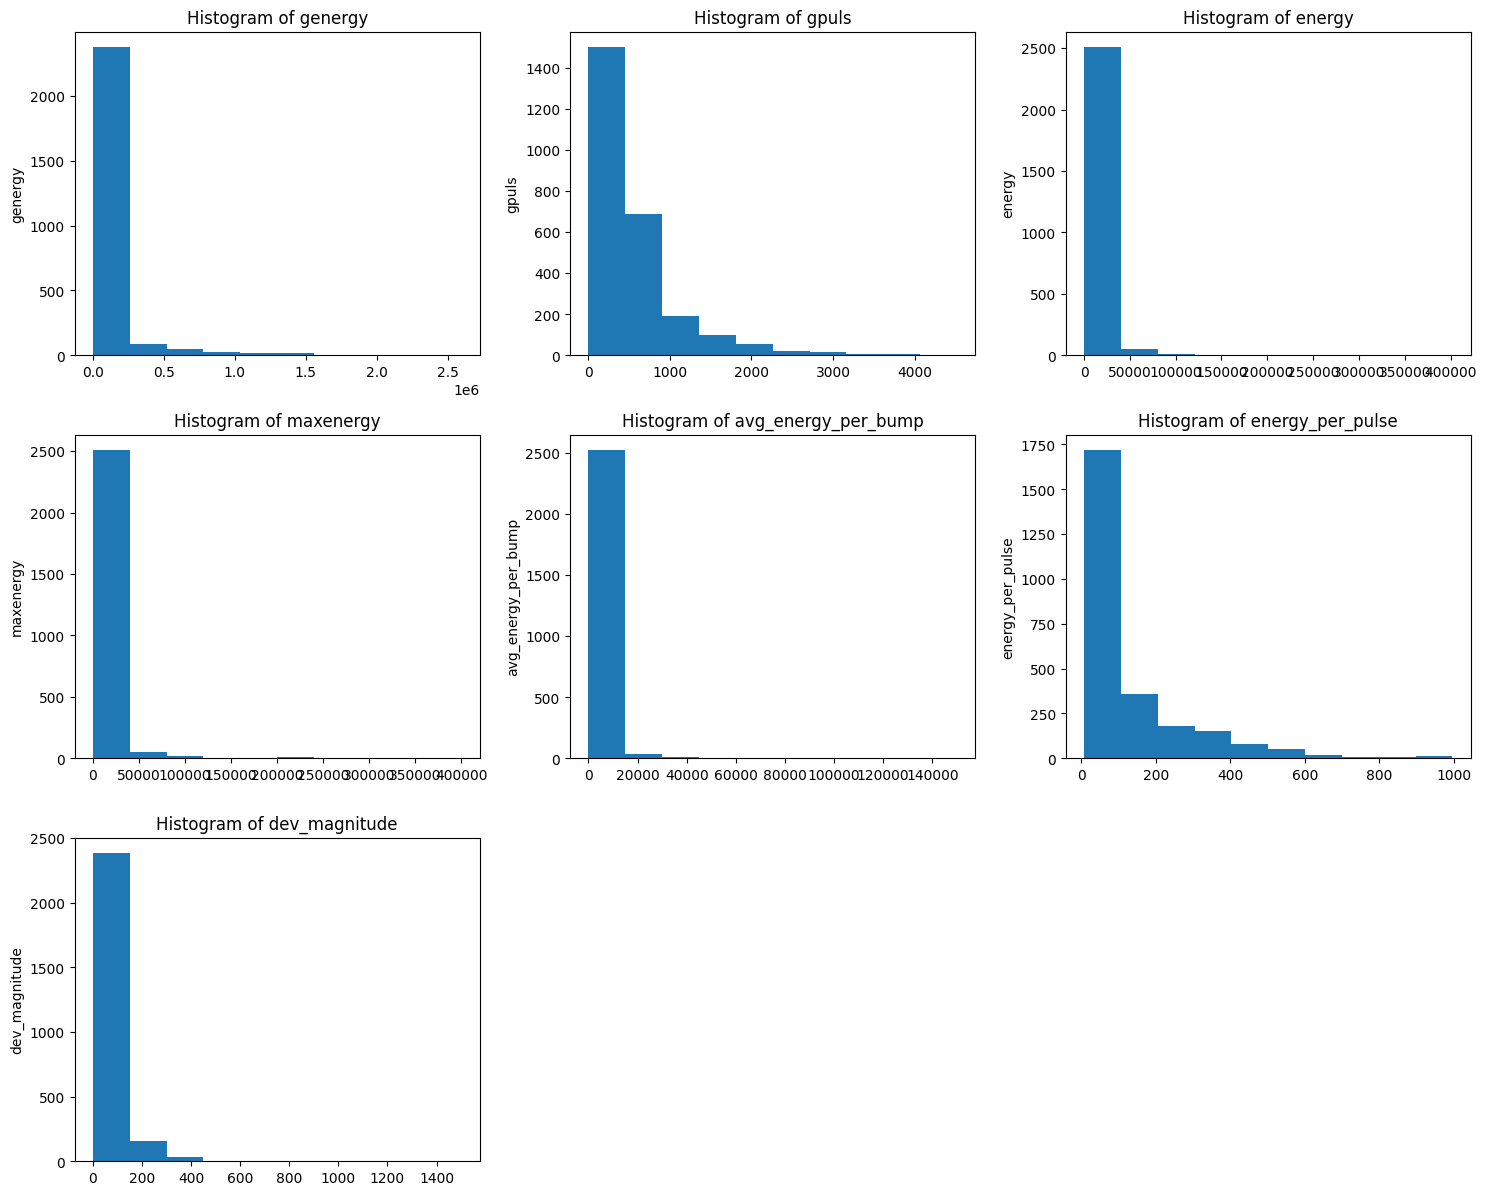

In [21]:
outliers_cols=['genergy', 'gpuls','energy', 'maxenergy','avg_energy_per_bump',
               'energy_per_pulse', 'dev_magnitude']
# check skeweness

# Calculate number of rows
n_rows = math.ceil(len(numerical_cols)/3)

# Create subplots
fig,axes = plt.subplots(
    n_rows,
    3,
    figsize=(15, 4 * n_rows)
)
# Flatten axes to make looping easier
axes = axes.flatten()
# make boxplot
for i, col in enumerate(outliers_cols):
    axes[i].hist(data[col])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Hide empty subplots
for i in range(len(outliers_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
data[outliers_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
genergy,2584.0,90242.523220,229200.508894,100.000000,11660.000000,25485.000000,52832.500000,2.595650e+06
gpuls,2584.0,538.579334,562.652536,2.000000,190.000000,379.000000,669.000000,4.518000e+03
energy,2584.0,4975.270898,20450.833222,0.000000,0.000000,0.000000,2600.000000,4.020000e+05
maxenergy,2584.0,4278.850619,19357.454882,0.000000,0.000000,0.000000,2000.000000,4.000000e+05
avg_energy_per_bump,2584.0,1586.377586,7139.888758,0.000000,0.000000,0.000000,1000.000000,1.500000e+05
energy_per_pulse,2584.0,132.390865,148.222429,7.163814,45.354047,70.286630,145.714428,9.967874e+02
dev_magnitude,2584.0,71.640636,74.029407,1.000000,31.890437,54.060147,86.886371,1.500756e+03


these histograms indicate all outliers columns are right skewed
I will use log1p to handle and transform outliers

In [23]:
for col in outliers_cols:
    data[col] = np.log1p(data[col])

Check outlier columns after transformation

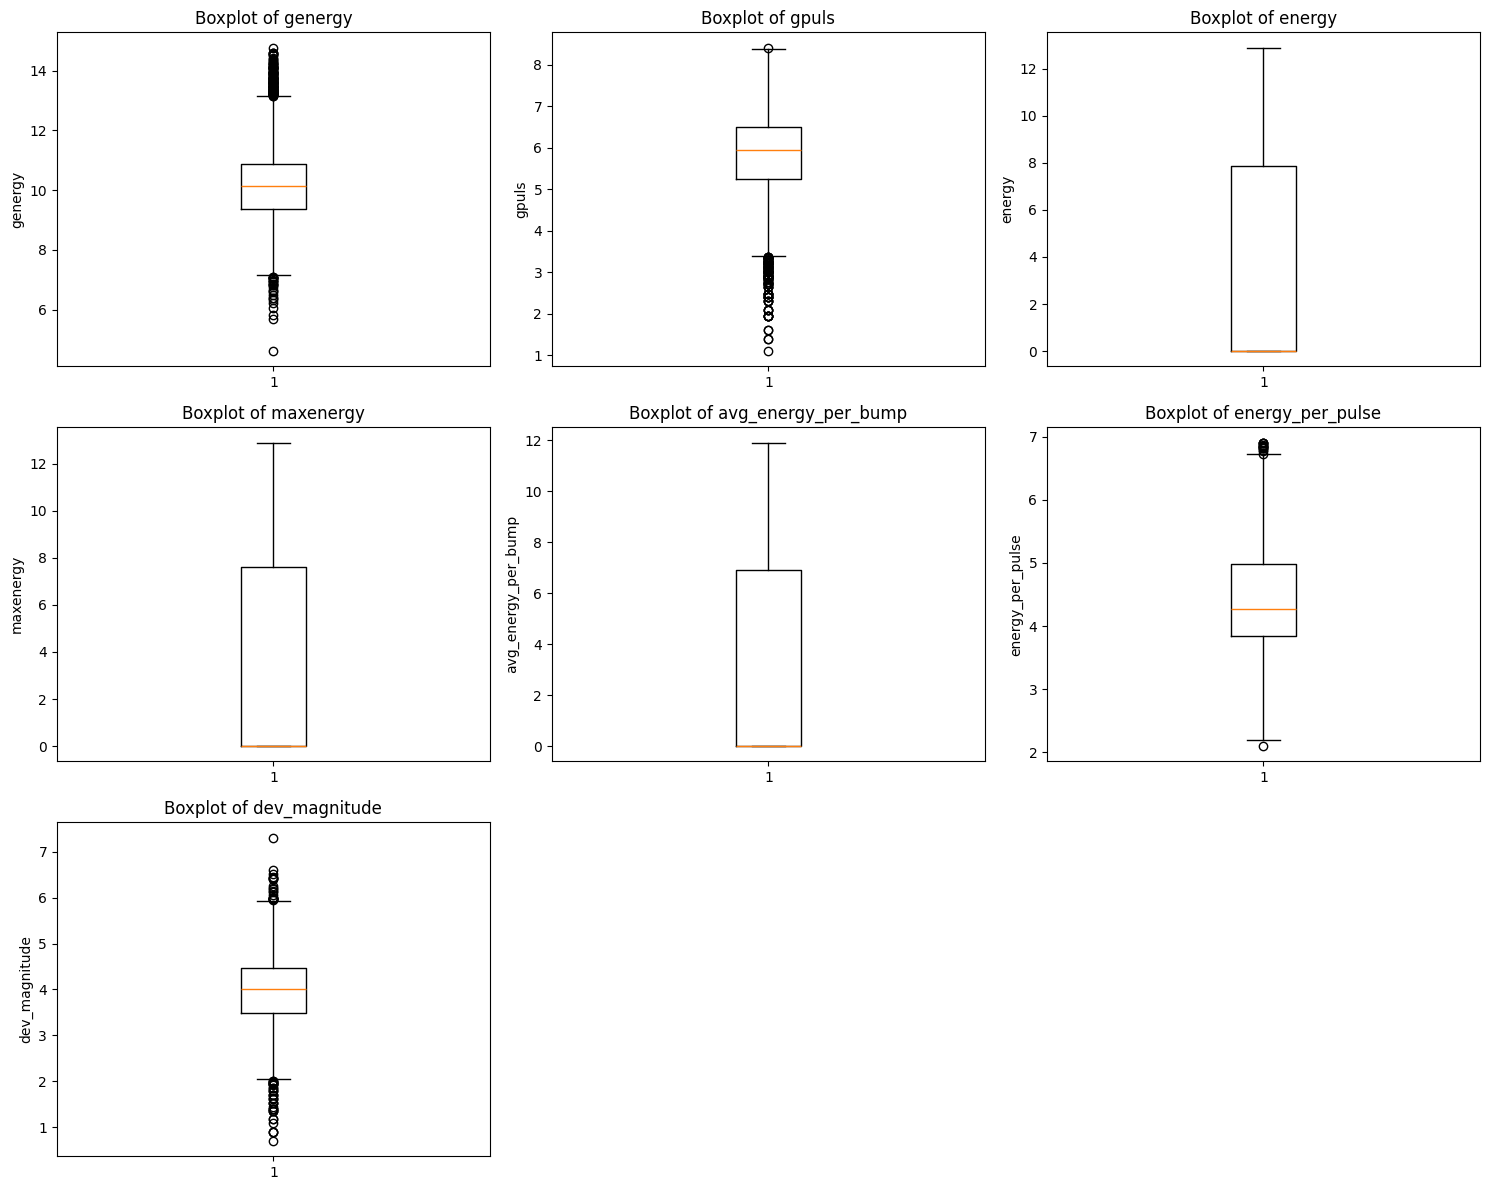

In [24]:
# Calculate number of rows
n_rows = math.ceil(len(outliers_cols)/3)

# Create subplots
fig,axes = plt.subplots(
    n_rows,
    3,
    figsize=(15, 4 * n_rows)
)
# Flatten axes to make looping easier
axes = axes.flatten()
# make boxplot
for i, col in enumerate(outliers_cols):
    axes[i].boxplot(data[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Hide empty subplots
for i in range(len(outliers_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
data[outliers_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
genergy,2584.0,10.221153,1.393800,4.615121,9.364005,10.145885,10.874899,14.769348
gpuls,2584.0,5.769602,1.160420,1.098612,5.252273,5.940171,6.507278,8.416046
energy,2584.0,3.481643,4.117081,0.000000,0.000000,0.000000,7.863651,12.904210
maxenergy,2584.0,3.398884,4.019217,0.000000,0.000000,0.000000,7.601402,12.899222
avg_energy_per_bump,2584.0,3.046380,3.609053,0.000000,0.000000,0.000000,6.908755,11.918397
energy_per_pulse,2584.0,4.467329,0.870472,2.099711,3.836309,4.266709,4.988488,6.905540
dev_magnitude,2584.0,3.962867,0.811721,0.693147,3.493182,4.008426,4.476044,7.314390


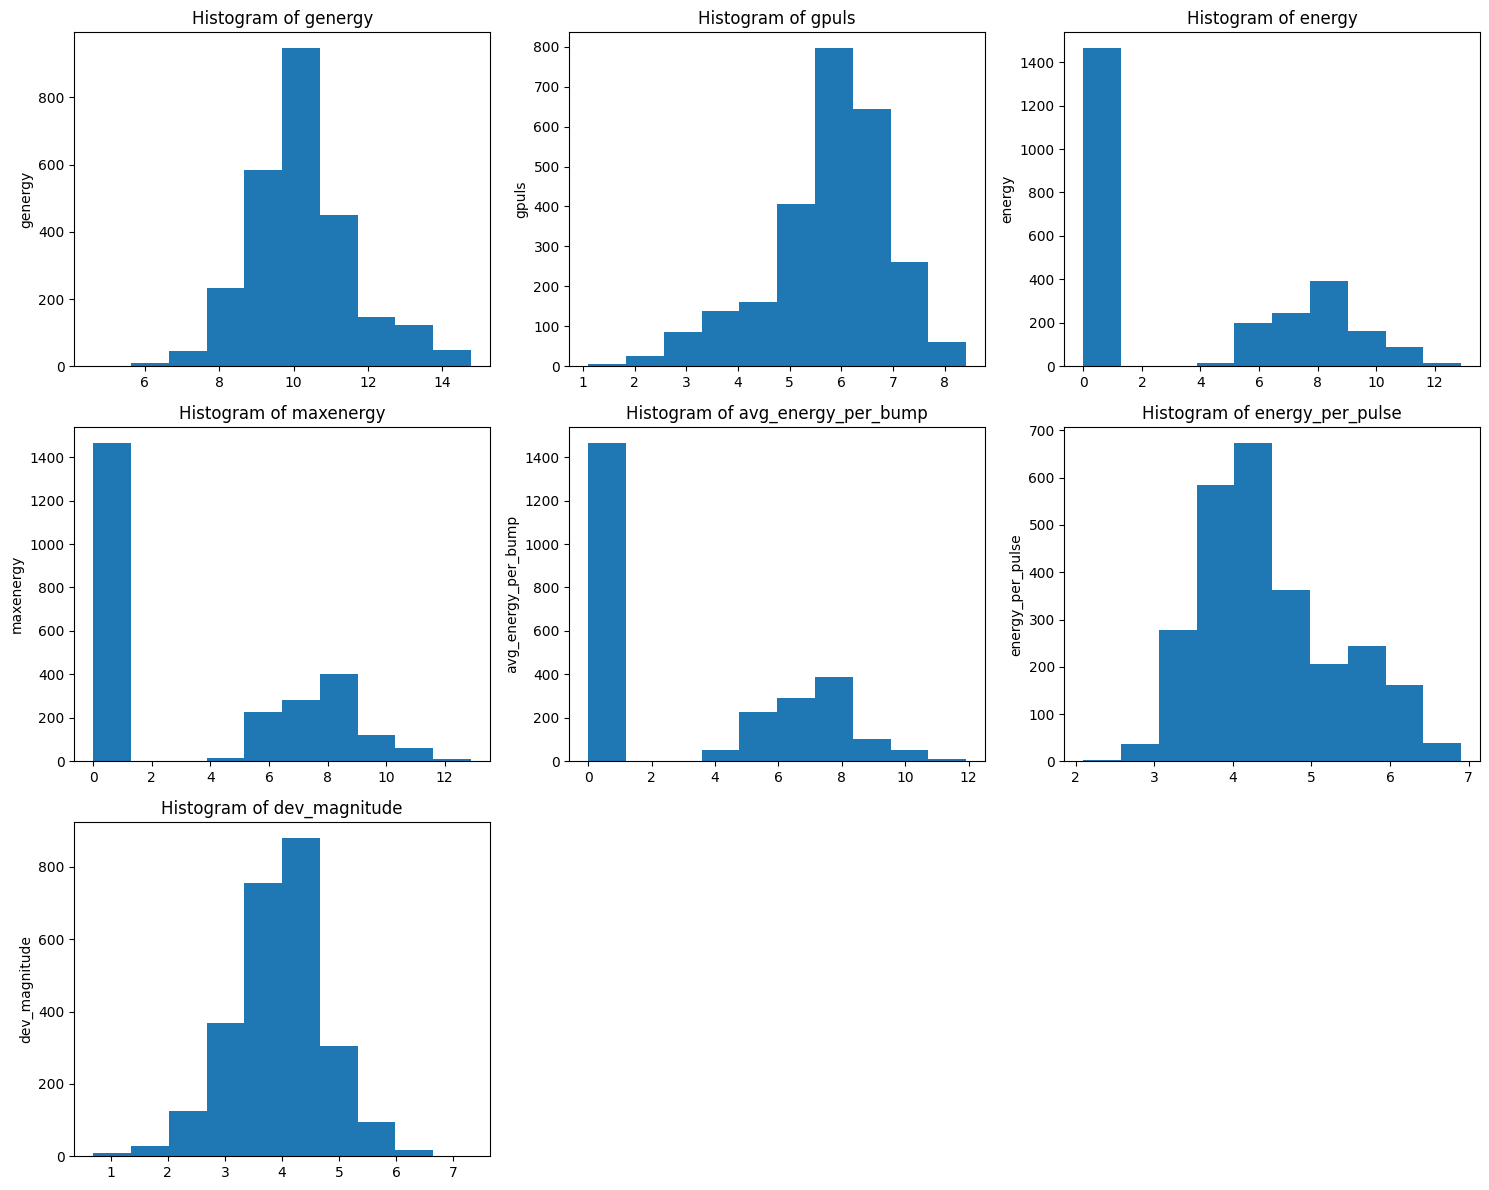

In [26]:
# check skeweness

# Calculate number of rows
n_rows = math.ceil(len(outliers_cols)/3)

# Create subplots
fig,axes = plt.subplots(
    n_rows,
    3,
    figsize=(15, 4 * n_rows)
)
# Flatten axes to make looping easier
axes = axes.flatten()
# make boxplot
for i, col in enumerate(outliers_cols):
    axes[i].hist(data[col])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Hide empty subplots
for i in range(len(outliers_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
data.head()

,id,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,...,high_energy_bumps,low_energy_bumps,high_energy_ratio,avg_energy_per_bump,energy_per_pulse,both_positive_dev,both_negative_dev,dev_magnitude,hazard_agreement,any_high_hazard
0,1,a,a,N,9.627800,3.891820,-72,-72,a,0,...,0,0,0.0,0.000000,5.739136,0,1,4.633013,True,0
1,2,a,a,N,9.597030,3.526361,-70,-79,a,1,...,0,1,0.0,6.908755,6.072909,0,1,4.668623,True,0
2,3,a,a,N,8.993552,3.433987,-81,-78,a,0,...,0,0,0.0,0.000000,5.563284,0,1,4.731362,True,0
3,4,a,a,N,10.268860,5.147494,-23,40,a,1,...,0,1,0.0,7.313887,5.127281,0,0,3.853145,True,0
4,5,a,a,N,9.444701,4.060443,-63,-52,a,0,...,0,0,0.0,0.000000,5.388757,0,1,4.415080,True,0


Save data to make EDA

In [28]:
data.to_csv("clean_data_for_EDA.csv",index=False)
print(f"shape: {data.shape}")

shape: (2584, 32)


## Encoding

In [29]:
categorical_cols

Index(['seismic', 'seismoacoustic', 'shift', 'ghazard'], dtype='object')

In [30]:
for col in categorical_cols:
  print(df[col].value_counts())
  print('='*50)

seismic
a    1682
b     902
Name: count, dtype: int64
seismoacoustic
a    1580
b     956
c      48
Name: count, dtype: int64
shift
W    1663
N     921
Name: count, dtype: int64
ghazard
a    2342
b     212
c      30
Name: count, dtype: int64


In [31]:
from sklearn.preprocessing import OrdinalEncoder
hazard_cols=['seismic','seismoacoustic','ghazard']
encoder=OrdinalEncoder(categories=[['a','b'],['a','b','c'],['a','b','c']]) # seismic has a,b but other have a,b,c
data[hazard_cols]=encoder.fit_transform(data[hazard_cols])

In [32]:
data = pd.get_dummies(data, columns=['shift'], drop_first=True, dtype=int)
data['hazard_agreement'] = data['hazard_agreement'].astype(int)

In [33]:
data.head()

,id,seismic,seismoacoustic,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,nbumps2,...,low_energy_bumps,high_energy_ratio,avg_energy_per_bump,energy_per_pulse,both_positive_dev,both_negative_dev,dev_magnitude,hazard_agreement,any_high_hazard,shift_W
0,1,0.0,0.0,9.627800,3.891820,-72,-72,0.0,0,0,...,0,0.0,0.000000,5.739136,0,1,4.633013,1,0,0
1,2,0.0,0.0,9.597030,3.526361,-70,-79,0.0,1,0,...,1,0.0,6.908755,6.072909,0,1,4.668623,1,0,0
2,3,0.0,0.0,8.993552,3.433987,-81,-78,0.0,0,0,...,0,0.0,0.000000,5.563284,0,1,4.731362,1,0,0
3,4,0.0,0.0,10.268860,5.147494,-23,40,0.0,1,0,...,1,0.0,7.313887,5.127281,0,0,3.853145,1,0,0
4,5,0.0,0.0,9.444701,4.060443,-63,-52,0.0,0,0,...,0,0.0,0.000000,5.388757,0,1,4.415080,1,0,0


### Drop useless columns

The EDA showed that `nbumps6`, `nbumps7` and `nbumps89` contain only zeros, so `has_high_energy_bump` (built from `nbumps89`) is also all zeros. They give the models no information, so we drop them before the split. (The EDA file was saved before this step, so the EDA notebook is not affected.)

In [34]:
constant_cols = ['nbumps6', 'nbumps7', 'nbumps89', 'has_high_energy_bump']

# check that they really are constant
print(data[constant_cols].nunique())

data = data.drop(columns=constant_cols)
print('shape after dropping:', data.shape)

nbumps6                 1
nbumps7                 1
nbumps89                1
has_high_energy_bump    1
dtype: int64
shape after dropping: (2584, 28)


## Train-test split

In [35]:
X = data.drop(columns=['id','class'])
y = data['class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [36]:
print('shape of train data: ',X_train.shape)
print('shape of test data: ',X_test.shape)

shape of train data:  (2067, 26)
shape of test data:  (517, 26)


## Scalling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Make SMOTE to handle imbalance data

In [38]:
# check imbalance
print(y_train.value_counts())
print(y_train.value_counts(normalize=True)*100)

class
0    1931
1     136
Name: count, dtype: int64
class
0    93.420416
1     6.579584
Name: proportion, dtype: float64


In [39]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(
    X_train_scaled,
    y_train
)

In [40]:
print("Before SMOTE:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True)*100)
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())
print(y_train_smote.value_counts(normalize=True)*100)

Before SMOTE:
class
0    1931
1     136
Name: count, dtype: int64
class
0    93.420416
1     6.579584
Name: proportion, dtype: float64

After SMOTE:
class
0    1931
1    1931
Name: count, dtype: int64
class
0    50.0
1    50.0
Name: proportion, dtype: float64


# modeling


**************************************************
Model: Logistic Regression
**************************************************
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.76      0.85       483
           1       0.16      0.62      0.25        34

    accuracy                           0.75       517
   macro avg       0.56      0.69      0.55       517
weighted avg       0.91      0.75      0.81       517

ROC-AUC Score: 0.7651


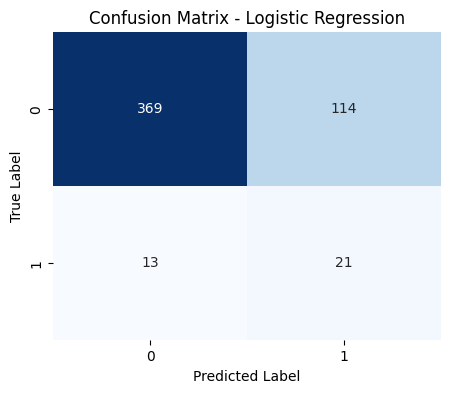


**************************************************
Model: Random Forest
**************************************************
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       483
           1       0.21      0.18      0.19        34

    accuracy                           0.90       517
   macro avg       0.58      0.57      0.57       517
weighted avg       0.89      0.90      0.90       517

ROC-AUC Score: 0.7245


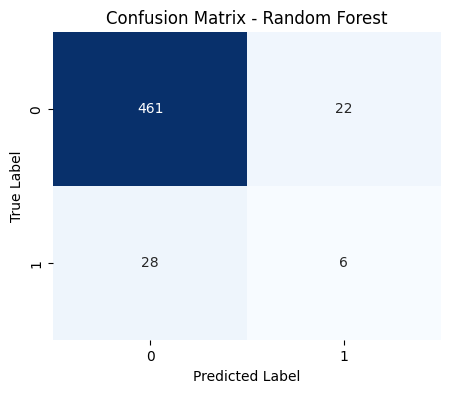


**************************************************
Model: XGBoost
**************************************************
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       483
           1       0.29      0.15      0.20        34

    accuracy                           0.92       517
   macro avg       0.62      0.56      0.58       517
weighted avg       0.90      0.92      0.91       517

ROC-AUC Score: 0.7414


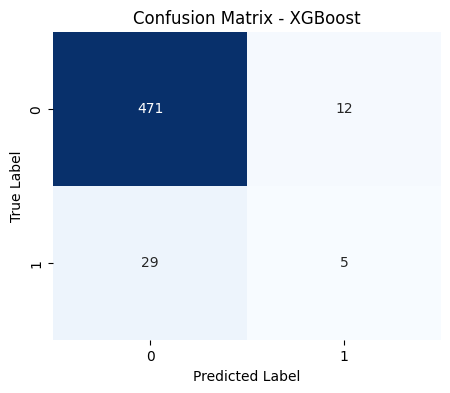

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


scale_pos = (len(y_train_smote) - sum(y_train_smote)) / sum(y_train_smote)


models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos)
}


for name, model in models.items():
    print(f"\n{'*'*50}")
    print(f"Model: {name}")
    print(f"{'*'*50}")


    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]


    print("Classification Report:")
    print(classification_report(y_test, y_pred))


    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC Score: {roc_auc:.4f}")

    #Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# 📊 Model Evaluation & Insights

### Key Insights from the Baseline Models

1. **Accuracy is misleading.** Only 6.6% of the shifts are hazardous, so a model can reach a high accuracy and still miss most hazardous shifts. We look at **Recall**, **F1** and **ROC-AUC** for class 1 instead.
2. **Random Forest and XGBoost** have high accuracy but a low recall for class 1, so they miss most hazardous shifts at the default threshold of 0.5.
3. **Logistic Regression** has lower accuracy but the highest recall for class 1. The price is a low precision (many false alarms). In a safety problem, missing a real hazard is worse than a false alarm.
4. **Next step:** the default threshold (0.5) is not ideal for imbalanced data, so we tune the Random Forest and then choose the decision threshold with cross-validation.

# Hyperparameter Tuning

In [42]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}


rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)


print("Tuning Random Forest...")
rf_random_search.fit(X_train_smote, y_train_smote)

print("Best Parameters for Random Forest:")
print(rf_random_search.best_params_)

best_rf = rf_random_search.best_estimator_
y_pred_tuned_rf = best_rf.predict(X_test_scaled)

print("\nClassification Report for Tuned Random Forest:")
print(classification_report(y_test, y_pred_tuned_rf))

Tuning Random Forest...
Best Parameters for Random Forest:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced_subsample'}

Classification Report for Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       483
           1       0.21      0.15      0.17        34

    accuracy                           0.91       517
   macro avg       0.57      0.55      0.56       517
weighted avg       0.89      0.91      0.90       517



# Threshold Tuning (with Cross-Validation)

Before, the threshold was compared on the **test set**, which makes the final numbers too optimistic. Here we do it properly:

1. Use **5-fold cross-validation on the training data** to get a probability for every training row.
2. Try many thresholds on these probabilities and pick the one with the best **F1** for class 1.
3. Use the **test set only once**, at the end, with the chosen threshold.

Inside each fold we scale and apply SMOTE using only that fold's training part, so nothing leaks into the validation part.

In [43]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

def get_cv_probabilities(model, X, y, n_splits=5):
    """For every training row, get the probability predicted by a model that did NOT see that row."""
    probs = np.zeros(len(y))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr = y.iloc[train_idx]

        # scale and balance using the training part of this fold only
        fold_scaler = StandardScaler()
        X_tr_scaled = fold_scaler.fit_transform(X_tr)
        X_val_scaled = fold_scaler.transform(X_val)
        X_tr_bal, y_tr_bal = SMOTE(random_state=42).fit_resample(X_tr_scaled, y_tr)

        model.fit(X_tr_bal, y_tr_bal)
        probs[val_idx] = model.predict_proba(X_val_scaled)[:, 1]

    return probs

In [44]:
# the two models we tune the threshold for
threshold_models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Tuned Random Forest": RandomForestClassifier(random_state=42, **rf_random_search.best_params_)
}

thresholds = np.arange(0.1, 0.9, 0.05)
best_thresholds = {}

for name, model in threshold_models.items():
    cv_probs = get_cv_probabilities(model, X_train, y_train)

    rows = []
    for th in thresholds:
        y_pred_th = (cv_probs >= th).astype(int)
        rows.append({
            'threshold': round(th, 2),
            'precision': precision_score(y_train, y_pred_th, zero_division=0),
            'recall': recall_score(y_train, y_pred_th),
            'f1': f1_score(y_train, y_pred_th)
        })
    results = pd.DataFrame(rows)

    best_row = results.loc[results['f1'].idxmax()]
    best_thresholds[name] = best_row['threshold']

    print(f"\n--- {name} (cross-validation on training data) ---")
    print(results.round(2).to_string(index=False))
    print(f"Best threshold by F1: {best_row['threshold']}")


--- Logistic Regression (cross-validation on training data) ---
 threshold  precision  recall   f1
      0.10       0.07    0.97 0.14
      0.15       0.08    0.92 0.14
      0.20       0.08    0.89 0.15
      0.25       0.09    0.88 0.16
      0.30       0.10    0.84 0.18
      0.35       0.11    0.78 0.19
      0.40       0.12    0.76 0.21
      0.45       0.13    0.70 0.22
      0.50       0.14    0.65 0.24
      0.55       0.15    0.60 0.24
      0.60       0.16    0.53 0.24
      0.65       0.18    0.46 0.26
      0.70       0.21    0.42 0.28
      0.75       0.20    0.30 0.24
      0.80       0.20    0.19 0.20
      0.85       0.23    0.12 0.16
Best threshold by F1: 0.7

--- Tuned Random Forest (cross-validation on training data) ---
 threshold  precision  recall   f1
      0.10       0.12    0.76 0.21
      0.15       0.14    0.71 0.24
      0.20       0.16    0.60 0.25
      0.25       0.16    0.47 0.24
      0.30       0.16    0.38 0.23
      0.35       0.18    0.35 0.24
    

## Final Evaluation on the Test Set

Now we use the test set **once**, with the thresholds chosen above.


**************************************************
Logistic Regression | threshold = 0.7
**************************************************
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       483
           1       0.26      0.41      0.32        34

    accuracy                           0.89       517
   macro avg       0.61      0.67      0.63       517
weighted avg       0.91      0.89      0.90       517

ROC-AUC Score: 0.7651


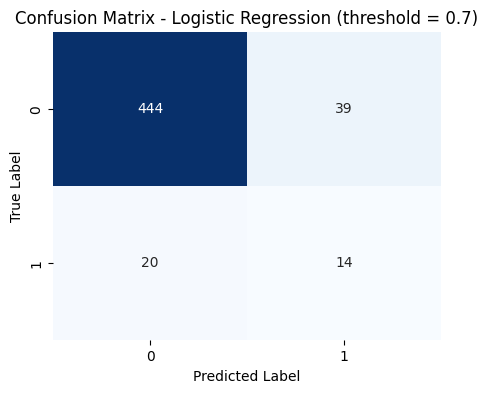


**************************************************
Tuned Random Forest | threshold = 0.2
**************************************************
              precision    recall  f1-score   support

           0       0.96      0.81      0.88       483
           1       0.17      0.56      0.26        34

    accuracy                           0.79       517
   macro avg       0.57      0.68      0.57       517
weighted avg       0.91      0.79      0.84       517

ROC-AUC Score: 0.7290


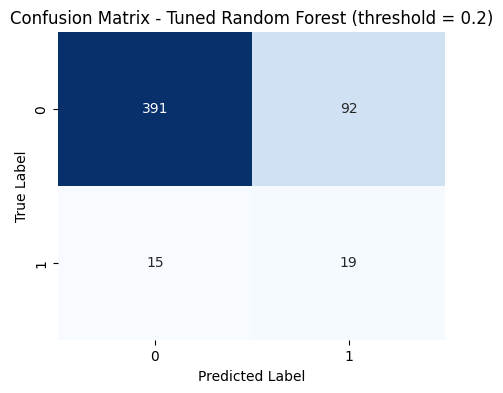

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

for name, model in threshold_models.items():
    # train on the full SMOTE training data, then predict on the untouched test set
    model.fit(X_train_smote, y_train_smote)
    test_probs = model.predict_proba(X_test_scaled)[:, 1]

    th = best_thresholds[name]
    y_pred_final = (test_probs >= th).astype(int)

    print(f"\n{'*'*50}")
    print(f"{name} | threshold = {th}")
    print(f"{'*'*50}")
    print(classification_report(y_test, y_pred_final))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, test_probs):.4f}")

    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {name} (threshold = {th})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

### Final Conclusion & Model Summary

1. **Imbalance:** only 6.6% of the shifts are hazardous, so accuracy alone is misleading. We used SMOTE (on the training data only), class weights, and judged the models with recall, F1 and ROC-AUC for class 1.
2. **Threshold:** it was chosen with 5-fold cross-validation on the training data (scaling and SMOTE inside each fold) and the test set was used only once at the end. This is more honest than choosing the threshold on the test set.
3. **Trade-off:** a lower threshold catches more hazardous shifts (higher recall) but gives more false alarms (lower precision). Since missing a hazardous shift is more costly, the team can choose a lower threshold if it accepts more false alarms.
4. **Limitation:** the test set contains only 34 hazardous shifts, so the metrics are noisy and should be read as approximate.

# Regression

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [47]:
# Columns we must NOT use as features:
# energy     -> this is the target
# maxenergy  -> leaks the target (the biggest bump is almost the whole energy)
# id, class  -> id is only a row number, class describes the NEXT shift
columns_to_drop = ['id', 'class', 'energy', 'maxenergy']

X = df.drop(columns=columns_to_drop)
y = df['energy']

# keep numeric columns only
X_numeric = X.select_dtypes(include=['number'])

# split and scale
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42)
}

In [49]:
for name, model in reg_models.items():
    print(f"\n{'*'*50}")
    print(f"Model: {name}")
    print(f"{'*'*50}")


    model.fit(X_train_scaled, y_train)


    y_pred = model.predict(X_test_scaled)


    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")


**************************************************
Model: Linear Regression
**************************************************
RMSE: 6498.3252
MAE:  1951.4356
R2 Score: 0.8666

**************************************************
Model: Random Forest Regressor
**************************************************
RMSE: 6863.9428
MAE:  1843.7195
R2 Score: 0.8511

**************************************************
Model: XGBoost Regressor
**************************************************
RMSE: 7702.0049
MAE:  2090.5801
R2 Score: 0.8125


In [50]:
# which features does the Random Forest use most?
importances = reg_models["Random Forest Regressor"].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_numeric.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("Top 5 features influencing the Energy prediction:")
print(feature_imp_df.head(5))

Top 5 features influencing the Energy prediction:
    Feature  Importance
8   nbumps5    0.604220
7   nbumps4    0.256322
2  gdenergy    0.033668
3    gdpuls    0.031070
6   nbumps3    0.026236


### Final Regression & Data Leakage Report (Conclusion)

1. **Leakage removed:** at first the R² was about 0.99 because `maxenergy` leaked the target (it had about 91% of the feature importance), so it was removed. `id` and `class` were also removed because they are not real input features.
2. **Model comparison:** use the RMSE, MAE and R² printed above to compare Linear Regression, Random Forest and XGBoost.
3. **Important limitation:** `nbumps4` and `nbumps5` count the bumps in the 10⁴–10⁶ J ranges, and the total `energy` is made of exactly these bumps. So they determine `energy` almost **by definition** (see the feature importance above), and the R² should be read as an optimistic upper bound, not as a pure prediction skill.